#Introducción

Esta es la tercera entrega del proyecto de inteligencia artificial 1, 2026-1, grupo C2.

Integrantes:
- Sergio Alejandro Ribero Ortiz - 2231885
- Nikolas Pedroso Mieles - 2231590
- Juan Gabriel García Jiménez - 2230083

### Dataset a utilizar

Para el proyecto, se decidió usar un dataset con 1000 entradas de peticiones de préstamos a un banco.
https://www.kaggle.com/datasets/amineipad/loan-approval-dataset

## Reto/Objetivo

Se desea desarrollar un estimador o predictor capaz de emular la toma de decisiones de la una entidad bancaria, específicamente respecto a su aprobación o rechazo de solicitudes de préstamos.

## Justificación IA

Debido a que no se conoce si depende de una fórmula o principio matemático, o si operadores humanos aceptan y rechazan cada caso bajo una evaluación individual, se considera que entrenar un modelo en base a resultados preexistentes asociados con la empresa es el mejor método disponible para crear una aproximación del criterio que se quiere estudiar.

##Características (features y target)

Se van a usar 6 características principales como features:

-Ingresos Anuales . . . . (Contínua)\
-Magnitud Crédito . . . .(Contínua)\
-Credit Score . . . . . . . . (Contínua)\
-No. Dependientes . . . .(Discreta: [0,4])\
-No. Créditos Vigentes (Discreta: [0,4])\
-Estado laboral . . . . . . .(Discreta: 3 estados)\
\
Por el otro lado, nuestra variable objetivo va a ser el estado de aprobación del crédito, pues al final del día es la aceptación o rechazo del crédito lo que termina importando para nuestros propósitos.

In [ ]:
#@title Librerías
import numpy as np              #Matemática y arreglos
import pandas as pd             #DataFrames y lectura del CSV
import matplotlib.pyplot as plt #Graficación
import seaborn as sns           #Graficación
from scipy import stats         #Distribuciones

import tensorflow as tf
from tensorflow import keras
from keras import layers
!pip install keras-tuner -q
import keras_tuner as kt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, classification_report

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#@title Cargar el dataset

df =  pd.read_csv("https://raw.githubusercontent.com/Khyii/ia1-los_banqueros-prediccion_aprobacion_de_prestamo/refs/heads/main/loan_approval.csv", sep=",").copy()

In [ ]:
#@title Procesamiento de datos

#Cambiar estado laboral a representación numérica
df.employment_status = df.employment_status.factorize()[0]
df

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,0,1
1,2,49,Male,Married,112197,23556,789,0,2,1,1
2,3,35,Male,Divorced,84429,27052,372,1,4,0,0
3,4,63,Female,Single,124195,11313,808,3,4,2,1
4,5,28,Female,Married,81627,13315,689,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
995,996,53,Female,Married,135598,6014,767,3,2,1,1
996,997,22,Male,Single,139028,15103,662,0,0,2,1
997,998,34,Female,Married,147517,21986,582,0,2,1,1
998,999,60,Female,Divorced,73161,49781,635,4,0,0,1


In [ ]:
dfc = df.copy()

dfc.drop(["applicant_id", "age", "gender", "marital_status"], axis=1, inplace=True)

dfc

,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,100073,7169,793,1,1,0,1
1,112197,23556,789,0,2,1,1
2,84429,27052,372,1,4,0,0
3,124195,11313,808,3,4,2,1
4,81627,13315,689,0,1,0,1
...,...,...,...,...,...,...,...
995,135598,6014,767,3,2,1,1
996,139028,15103,662,0,0,2,1
997,147517,21986,582,0,2,1,1
998,73161,49781,635,4,0,0,1


In [ ]:
#@title Asignación de features

FEATURES = [
    'annual_income',        # Ingresos Anuales      — continua
    'loan_amount',          # Magnitud Crédito      — continua
    'credit_score',         # Credit Score          — continua
    'num_dependents',       # No. Dependientes      — discreta [0,4]
    'existing_loans_count', # No. Créditos Vigentes — discreta [0,4]
    'employment_status',    # Estado Laboral        — categórica 3 estados => [0,2]
]
TARGET = 'loan_approved'

X = df[FEATURES]
y = df[TARGET]

In [ ]:
#@title Escalado de datos

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos escalados correctamente.")
print(f"Media por feature (debe ser ~0): {X_scaled.mean(axis=0).round(2)}")
print(f"Desv. Est por feature (debe ser ~1): {X_scaled.std(axis=0).round(2)}")

Datos escalados correctamente.
Media por feature (debe ser ~0): [ 0. -0.  0. -0.  0. -0.]
Desv. Est por feature (debe ser ~1): [1. 1. 1. 1. 1. 1.]


# Deep Learning

In [ ]:
#@title Definición del modelo con hiperparámetros tuneables
def build_model(hp):
    model = keras.Sequential()

    # Capa de entrada explícita
    model.add(keras.Input(shape=(X_scaled.shape[1],)))

    # Número de capas ocultas: 1, 2 o 3
    for i in range(hp.Int('num_layers', min_value=1, max_value=3)):
        model.add(layers.Dense(
            units=hp.Choice(f'units_{i}', values=[16, 32, 64]),
            activation=hp.Choice('activation', ['relu', 'tanh'])
        ))
        model.add(layers.Dropout(
            rate=hp.Float('dropout', min_value=0.0, max_value=0.4, step=0.1)
        ))

    # Capa de salida — sigmoid para clasificación binaria
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [0.001, 0.005, 0.01])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
#@title Random Search (10 combinaciones)
tf.random.set_seed(21)

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,           # Rápido: 10 combinaciones
    executions_per_trial=2,  # Cada combinación se prueba 2 veces para estabilidad
    seed=21,
    directory='tuning_logs',
    project_name='loan_approval_nn',
    overwrite=True
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

print("Iniciando Random Search...")
tuner.search(
    X_scaled, np.array(y),
    epochs=60,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print("\nBúsqueda finalizada.")

Iniciando Random Search...

Búsqueda finalizada.


In [ ]:
#@title Resultados del Random Search
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=" * 50)
print("  MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("=" * 50)
print(f"  Capas ocultas   : {best_hps.get('num_layers')}")
print(f"  Activación      : {best_hps.get('activation')}")
print(f"  Learning Rate   : {best_hps.get('learning_rate')}")
print(f"  Dropout         : {best_hps.get('dropout'):.1f}")

for i in range(best_hps.get('num_layers')):
    print(f"  Neuronas capa {i+1} : {best_hps.get(f'units_{i}')}")

# Resumen de todos los trials para incluir en el informe
print("\n" + "=" * 50)
print("  RESUMEN DE TODOS LOS TRIALS")
print("=" * 50)
for trial in tuner.oracle.get_best_trials(num_trials=10):
    print(f"  Trial {trial.trial_id} | val_accuracy: {trial.score:.4f} | "
          f"Params: {trial.hyperparameters.values}")

  MEJORES HIPERPARÁMETROS ENCONTRADOS
  Capas ocultas   : 3
  Activación      : tanh
  Learning Rate   : 0.01
  Dropout         : 0.0
  Neuronas capa 1 : 32
  Neuronas capa 2 : 16
  Neuronas capa 3 : 32

  RESUMEN DE TODOS LOS TRIALS
  Trial 05 | val_accuracy: 0.9925 | Params: {'num_layers': 3, 'units_0': 32, 'activation': 'tanh', 'dropout': 0.0, 'learning_rate': 0.01, 'units_1': 16, 'units_2': 32}
  Trial 08 | val_accuracy: 0.9825 | Params: {'num_layers': 1, 'units_0': 64, 'activation': 'relu', 'dropout': 0.1, 'learning_rate': 0.01, 'units_1': 64, 'units_2': 16}
  Trial 00 | val_accuracy: 0.9725 | Params: {'num_layers': 1, 'units_0': 64, 'activation': 'tanh', 'dropout': 0.30000000000000004, 'learning_rate': 0.005}
  Trial 01 | val_accuracy: 0.9700 | Params: {'num_layers': 3, 'units_0': 32, 'activation': 'relu', 'dropout': 0.2, 'learning_rate': 0.005, 'units_1': 16, 'units_2': 16}
  Trial 07 | val_accuracy: 0.9700 | Params: {'num_layers': 1, 'units_0': 16, 'activation': 'tanh', 'dropou

In [ ]:
#@title Evaluación final — Stratified K-Fold (k=10)


skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=21)

f1_scores_nn  = []
acc_scores_nn = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = np.array(y)[train_idx], np.array(y)[test_idx]

    # Escalar DENTRO del fold para evitar data leakage
    fold_scaler = StandardScaler()
    X_train = fold_scaler.fit_transform(X_train)
    X_test  = fold_scaler.transform(X_test)

    # Construir modelo con los mejores hiperparámetros
    model = tuner.hypermodel.build(best_hps)

    model.fit(
        X_train, y_train,
        epochs=60,
        batch_size=32,
        callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)],
        verbose=0
    )

    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

    f1_scores_nn.append(f1_score(y_test, y_pred, average='weighted'))
    acc_scores_nn.append(accuracy_score(y_test, y_pred))
    print(f"  Fold {fold+1:02d} | Accuracy: {acc_scores_nn[-1]:.4f} | F1-Weighted: {f1_scores_nn[-1]:.4f}")

print("\n" + "=" * 50)
print("  RESULTADO FINAL — Red Neuronal")
print("=" * 50)
print(f"  Accuracy : {np.mean(acc_scores_nn):.4f} ± {np.std(acc_scores_nn):.4f}")
print(f"  F1-Weighted : {np.mean(f1_scores_nn):.4f} ± {np.std(f1_scores_nn):.4f}")

  Fold 01 | Accuracy: 0.9800 | F1-Weighted: 0.9800
  Fold 02 | Accuracy: 0.9900 | F1-Weighted: 0.9901


  Fold 03 | Accuracy: 0.9700 | F1-Weighted: 0.9702
  Fold 04 | Accuracy: 0.9900 | F1-Weighted: 0.9901
  Fold 05 | Accuracy: 0.9900 | F1-Weighted: 0.9899
  Fold 06 | Accuracy: 0.9900 | F1-Weighted: 0.9899
  Fold 07 | Accuracy: 0.9900 | F1-Weighted: 0.9899
  Fold 08 | Accuracy: 0.9400 | F1-Weighted: 0.9407
  Fold 09 | Accuracy: 1.0000 | F1-Weighted: 1.0000
  Fold 10 | Accuracy: 0.9700 | F1-Weighted: 0.9702

  RESULTADO FINAL — Red Neuronal
  Accuracy : 0.9810 ± 0.0164
  F1-Weighted : 0.9811 ± 0.0162


 ### Librería: TensorFlow/Keras

Se seleccionó **TensorFlow/Keras** como framework para la implementación de la red neuronal por las siguientes razones:
 - **Integración con Keras Tuner:** Keras Tuner fue desarrollado  específicamente para el ecosistema Keras, lo que permite definir  los hiperparámetros directamente dentro de la función de construcción  del modelo (`build_model`) de forma limpia y reproducible.
 - **Compatibilidad con el entorno:** TensorFlow viene preinstalado en Google Colab, por lo que no requiere configuración adicional y garantiza estabilidad en la ejecución.
- **API de alto nivel:** La API secuencial de Keras permite construir,  compilar y entrenar redes neuronales con pocas líneas de código, lo que  facilita la legibilidad del notebook y la reproducibilidad del experimento.
 - **Consistencia con el proyecto:** Las demás librerías utilizadas (scikit-learn, pandas, numpy) son totalmente compatibles con TensorFlow,  permitiendo reutilizar el preprocesamiento y las estructuras de evaluación ya definidas en entregas anteriores.

# No Supervisado

### K-Means (reducción dimensionalidad por PCA)

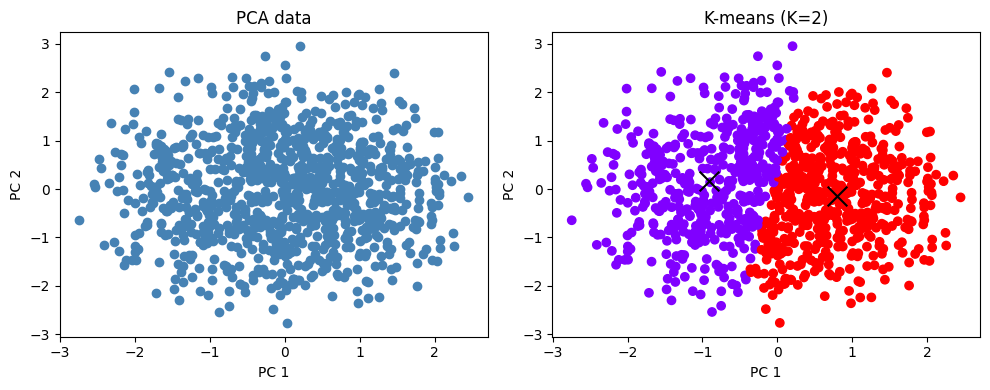

In [ ]:
pca = PCA(n_components = 2, random_state=21)
X_pca = pca.fit_transform(X_scaled)

n_clusters=2
k_mean_model = KMeans(n_clusters=n_clusters, random_state=21)
k_mean_model.fit(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c='steelblue')
axes[0].set_title('PCA data')
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=k_mean_model.labels_, cmap='rainbow')
axes[1].scatter(
    k_mean_model.cluster_centers_[:, 0],
    k_mean_model.cluster_centers_[:, 1],
    color='black', marker='x', s=200,
)
axes[1].set_title('K-means (K=2)')
for ax in axes:
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
plt.tight_layout()

###Reductor de Dimensiones (PCA)

Explained variance — PC1: 18.4%, PC2: 18.0%, cumulative: 36.4%


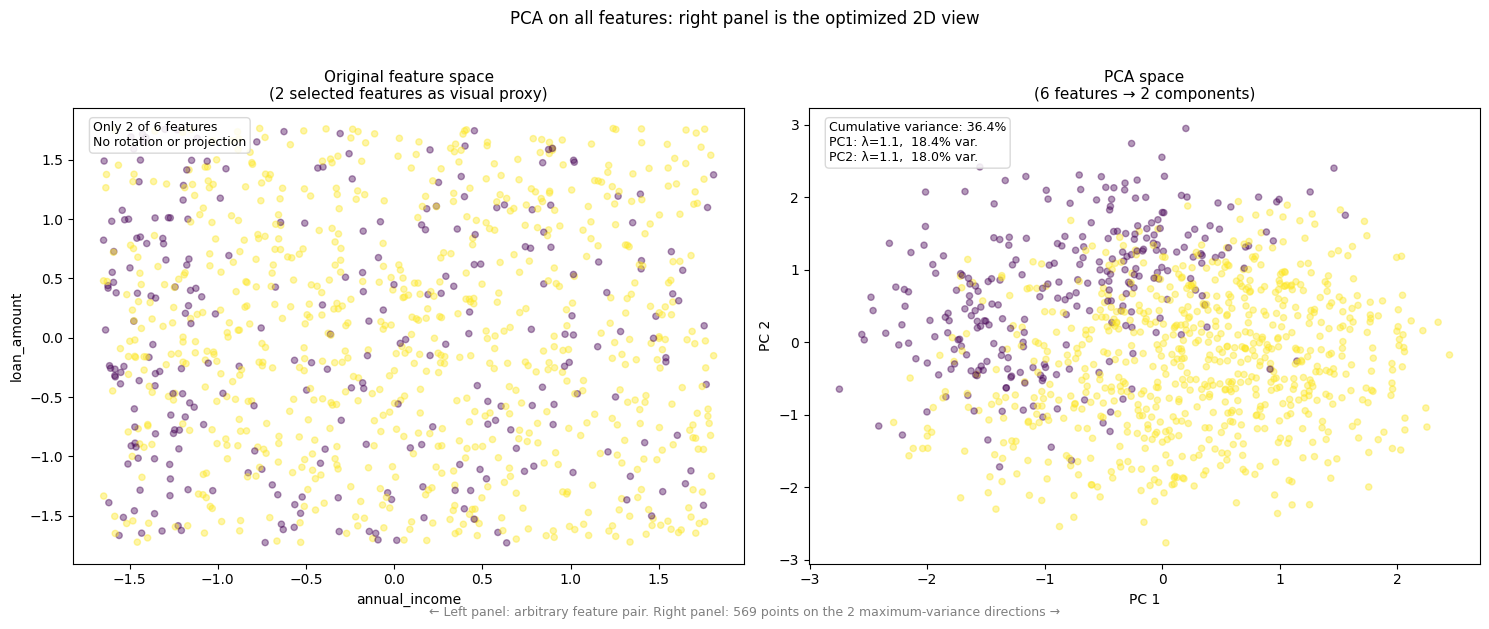

In [ ]:
explained = pca.explained_variance_
ratio = pca.explained_variance_ratio_
print(f"Explained variance — PC1: {ratio[0]:.1%}, PC2: {ratio[1]:.1%}, cumulative: {ratio.sum():.1%}")

feature1 = 0
feature2 = 1

feat_x = FEATURES[feature1]
feat_y = FEATURES[feature2]

fig, (ax_orig, ax_pca) = plt.subplots(1, 2, figsize=(15, 6))

ax_orig.scatter(
    X_scaled[:, feature1], X_scaled[:, feature2], c=y, alpha=0.4, s=20
)
ax_orig.set_xlabel(feat_x)
ax_orig.set_ylabel(feat_y)
ax_orig.set_title(
    "Original feature space\n(2 selected features as visual proxy)",
    fontsize=11,
)
ax_orig.text(
    0.03,
    0.97,
    f"Only 2 of {X.shape[1]} features\nNo rotation or projection",
    transform=ax_orig.transAxes,
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="lightgray"),
)

ax_pca.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.4, s=20)
ax_pca.set_xlabel("PC 1")
ax_pca.set_ylabel("PC 2")
ax_pca.set_title(
    f"PCA space\n({X.shape[1]} features → 2 components)",
    fontsize=11,
)
stats = (
    f"Cumulative variance: {ratio.sum():.1%}\n"
    f"PC1: λ={explained[0]:.1f},  {ratio[0]:.1%} var.\n"
    f"PC2: λ={explained[1]:.1f},  {ratio[1]:.1%} var."
)
ax_pca.text(
    0.03,
    0.97,
    stats,
    transform=ax_pca.transAxes,
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="lightgray"),
)

fig.suptitle(
    "PCA on all features: right panel is the optimized 2D view",
    fontsize=12,
    y=1.02,
)
fig.text(
    0.5,
    0.01,
    "← Left panel: arbitrary feature pair. "
    "Right panel: 569 points on the 2 maximum-variance directions →",
    ha="center",
    fontsize=9,
    color="gray",
)
plt.tight_layout()
plt.show()
